# Model predicting pregnancy outcome from the second trimester maternal plasma proteomics

In [1]:
import pandas as pd

In [2]:
second_trimester = pd.read_csv('../output/tarca_et_al_2021/norm_log2t_batch_corrected_integrated_dataset_second_trimester.csv')
second_trimester

,Accession,GEO_accession,Group,GA_delivery,Target,Log2RFU
0,GSM4525301,GSE150167,Control,40.1,14-3-3,0.835382
1,GSM4525302,GSE150167,sPTD,34.1,14-3-3,0.822620
2,GSM4525303,GSE150167,PPROM,36.7,14-3-3,0.834636
3,GSM4525304,GSE150167,sPTD,35.0,14-3-3,0.850609
4,GSM4525305,GSE150167,sPTD,36.0,14-3-3,0.822708
...,...,...,...,...,...,...
433375,GSM6254820,GSE206454,Control,NaN,vWF,0.991198
433376,GSM6254821,GSE206454,Control,NaN,vWF,0.993465
433377,GSM6254823,GSE206454,Control,NaN,vWF,1.003324
433378,GSM6254828,GSE206454,Control,NaN,vWF,1.005959


In [3]:
third_trimester = pd.read_csv('../output/tarca_et_al_2021/norm_log2t_batch_corrected_integrated_dataset_third_trimester.csv')
third_trimester

,Accession,GEO_accession,Group,GA_delivery,Target,Log2RFU
0,GSM4525406,GSE150167,Control,40.1,14-3-3,0.854517
1,GSM4525407,GSE150167,sPTD,34.1,14-3-3,0.853892
2,GSM4525408,GSE150167,PPROM,36.7,14-3-3,0.853894
3,GSM4525409,GSE150167,sPTD,35.0,14-3-3,0.865530
4,GSM4525410,GSE150167,sPTD,36.0,14-3-3,0.861809
...,...,...,...,...,...,...
379785,GSM6254825,GSE206454,Control,NaN,vWF,1.000289
379786,GSM6254826,GSE206454,Control,NaN,vWF,0.982881
379787,GSM6254827,GSE206454,Control,NaN,vWF,0.990403
379788,GSM6254830,GSE206454,Control,NaN,vWF,1.002559


In [4]:
percentile_change = ["IL-17B", "OX40 Ligand", "FGF-12", "DSC3", "NANOG", "IL-12", "RTN4", "DcR3", "IgG", "HPV E7 Type 16", "D-dimer", "TNR4", "CD70", "FGF-12", "NKp30", "GPC2", "SSRP1", "EG-VEGF", "Arylsulfatase A", "STX1a"]
pca_loadings = ['Thrombin', 'Soggy-1', 'a2-Macroglobulin', 'Cadherin-6', 'IL-17 RC', 'Prothrombin', 'SIRT2', 'OBCAM', 'YES', 'amyloid precursor protein', 'PIM1', 'MRCKB', 'C4b', 'P-Selectin', 'STX1a', 'Apo B', 'SPARCL1', 'Calcineurin B a', 'MMEL2', 'CSF-1', 'Flt-3', 'Protease nexin I', 'HIPK3', 'a1-Antichymotrypsin', 'GOT1', 'JAK2', 'IGFBP-6', 'NOTC2', 'PCSK7', 'C3a', 'METAP1', 'PKC-B-II', 'Integrin a1b1', 'FER', 'Clusterin', 'TSP4', 'IF4A3', 'GPC5', 'LG3BP', 'Glucagon', 'PTHrP', 'LYVE1', 'Coagulation Factor V', 'TIMP-1', 'LAG-3', 'M2-PK', 'CAMK2B', 'H6ST1', 'CAMK2D', 'Coagulation Factor VII'] # top 25 positive and negative PC1 loadings in second-trimester
perc_90 = ["Cyclophilin A", "CNTF", "CS084", "IL-7 Ra", "Cyclin B1", "CLC4K", "transcription factor MLR1, isoform CRA_b", "IL-17B", "UBE2N", "IL-17 RD", "SGTA", "TGF-b3", "LDH-H 1", "HSP 40", "CD70", "CaMKK alpha", "FGF-17", "F229A", "Stress-induced-phosphoprotein 1", "Ephrin-A4", "b-ECGF", "IFN-g", "ADAMTS-5", "Cyclophilin F", "IFN-lambda 2", "GCKR", "CDC37", "IMB1", "uPA", "IL-12 Rb1", "JAM-C", "DRAK2", "Sphingosine kinase 1", "OX40 Ligand", "UB2L3", "FGF-12", "PDGF-BB", "EF-1-beta", "DSC3", "AMNLS", "Enterokinase", "FGF-18", "ATS15", "ERK-1", "Lymphotactin", "HMGR", "KIRR3", "PSA6", "Persephin", "ABL1"]
perc_10 = ["PDGF-CC", "FGF-20", "IgE", "IgM", "DEAD-box protein 19B", "Arylsulfatase A", "Cyclophilin A", "DcR3", "FCG2A/B", "GIIE", "HPV E7 Type 16", "IL-18 Ra", "IL-23", "LIMP II", "MAPKAPK3", "MEPE", "PPAC", "Rb", "TS", "VEGF-C", "carbonic anhydrase II", "dopa decarboxylase", "gpIIbIIIa", "transcription factor MLR1, isoform CRA_b", "IL-12 RB2", "C5b, 6 Complex", "IgD", "DSC3", "D-dimer", "b-Endorphin", "EMR2", "Galectin-8", "TS", "TNR4", "IL-17B", "ENA-78", "IL-15 Ra", "IL-10", "PKC-G", "Integrin a1b1", "C5b, 6 Complex", "CD70", "CDK5/p35", "CNTF", "Contactin-4", "DLL4", "EDA", "EMR2", "FGF9", "GFRa-1"]
de_targets = ['METAP1', 'JAK2', 'SPARCL1', 'SET', 'LYVE1', 'GPC5', 'SIRT2', 'UBE2N', 'FER', 'CAMK1', 'CAMK2B', 'CAMK2D', 'PIM1', 'PCSK7', 'CAMK2A', 'NR1D1', 'LIN7B', 'GAS1', 'PA2G4', 'PDPK1', 'GDF2', 'PTN', 'PARK7', 'CPNE1', 'PDK1', 'HIPK3', 'DSC3', 'BOC', 'C5', 'GOT1', 'MAPKAPK3', 'LY86', 'LY9', 'FYN', 'GREM1', 'PTH', 'UFM1', 'DMP1', 'MICA', 'FGFR4', 'COLEC12', 'RBM39', 'CKAP2', 'GPC2', 'PPIE', 'PCNA', 'CDON', 'PRL', 'ERP29', 'IL24']

90th percentile, PCA loadings, and DE targets are both from second trimester. 

In [5]:
# Define your target groups in a dictionary
target_groups = {
    "pca": pca_loadings,
    "percentiles": percentile_change,
    "90th": perc_90,
    "10th": perc_10,
    "de": de_targets
}

# Dictionary to hold results
results = {}

# Loop through each group and filter
# Create variables and verify
for name, targets in target_groups.items():
    globals()[f"second_trimester_{name}"] = second_trimester.loc[second_trimester['Target'].isin(targets)]
    globals()[f"third_trimester_{name}"] = third_trimester.loc[third_trimester['Target'].isin(targets)]
    print(f"Created variables: second_trimester_{name}, third_trimester_{name}")

Created variables: second_trimester_pca, third_trimester_pca
Created variables: second_trimester_percentiles, third_trimester_percentiles
Created variables: second_trimester_90th, third_trimester_90th
Created variables: second_trimester_10th, third_trimester_10th
Created variables: second_trimester_de, third_trimester_de


In [6]:
import preprocess_model_data

for fname in target_groups.keys():
    globals()[f"full_data_{fname}"] = preprocess_model_data.process_model_data(
        globals()[f"second_trimester_{fname}"], 
        globals()[f"third_trimester_{fname}"], 
        model='outcome'
    )

c:\Users\doram\Desktop\Masters\RP-2\code\preprocess_model_data.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  second_trimester_data.loc[:, 'Group'] = second_trimester_data['Group'].replace(mapping)
c:\Users\doram\Desktop\Masters\RP-2\code\preprocess_model_data.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  third_trimester_data.loc[:, 'Group'] = third_trimester_data['Group'].replace(mapping)
c:\Users\doram\Desktop\Masters\RP-2\code\preprocess_model_data.py:31: FutureWarning: Downcasting behavior in `replace` is deprecat

# Model building

In [7]:
# Automate inference sampling and data splitting
for fname in target_groups.keys():
    # Get the full data variable
    full_data_var = globals()[f"full_data_{fname}"]
    
    # Create inference samples
    inference_samples = full_data_var.groupby('Group', group_keys=False).sample(n=5, random_state=42)
    globals()[f"inference_samples_{fname}"] = inference_samples
    
    # Remove inference samples from original data
    remaining_data = full_data_var.drop(inference_samples.index)
    globals()[f"full_data_{fname}2"] = remaining_data
    
    print(f"Created: inference_samples_{fname} (shape: {inference_samples.shape})")
    print(f"Created: full_data_{fname}2 (shape: {remaining_data.shape})")

Created: inference_samples_pca (shape: (10, 52))
Created: full_data_pca2 (shape: (680, 52))
Created: inference_samples_percentiles (shape: (10, 21))
Created: full_data_percentiles2 (shape: (680, 21))
Created: inference_samples_90th (shape: (10, 52))
Created: full_data_90th2 (shape: (680, 52))
Created: inference_samples_10th (shape: (10, 49))
Created: full_data_10th2 (shape: (680, 49))
Created: inference_samples_de (shape: (10, 52))
Created: full_data_de2 (shape: (680, 52))


In [8]:
XY = {}

for key in target_groups.keys():
    # Get the processed data
    full_data_var = globals()[f"full_data_{key}2"]
    
    # Create X (features)
    X_var = full_data_var.drop(columns=['Accession', 'Group'])
    
    # Create y (targets) - original
    y_var_original = full_data_var['Group']
    
    # Convert y to integer
    y_var = y_var_original.astype(int)
    
    # Store variables
    globals()[f"X_{key}"] = X_var
    globals()[f"y_{key}"] = y_var
    XY[key] = (X_var, y_var)
    
    print(f"Created: X_{key} (shape: {X_var.shape})")
    print(f"Created: y_{key} - converted from {y_var_original.dtype} to {y_var.dtype} (shape: {y_var.shape})")

Created: X_pca (shape: (680, 50))
Created: y_pca - converted from object to int64 (shape: (680,))
Created: X_percentiles (shape: (680, 19))
Created: y_percentiles - converted from object to int64 (shape: (680,))
Created: X_90th (shape: (680, 50))
Created: y_90th - converted from object to int64 (shape: (680,))
Created: X_10th (shape: (680, 47))
Created: y_10th - converted from object to int64 (shape: (680,))
Created: X_de (shape: (680, 50))
Created: y_de - converted from object to int64 (shape: (680,))


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.model_selection import LearningCurveDisplay

# Bundle your datasets into a dictionary
datasets = {
    "PC1 loadings": full_data_pca2,
    "DE proteins": full_data_de2,
    "10th percentile": full_data_10th2,
    "90th-to-10th percentile": full_data_percentiles2,
    "90th percentile": full_data_90th2
}

# Split into (X, y) automatically
XY = {
    name: (
        df.drop(columns=['Accession', 'Group']),
        df['Group'].astype(int).values
    )
    for name, df in datasets.items()
}

# Define pipeline
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=300, 
        max_depth=1,
        min_samples_split=10, 
        min_samples_leaf=10, 
        class_weight='balanced',
        bootstrap=True,
        ccp_alpha=0.5, 
        random_state=0
    ))
])

cv = StratifiedKFold(n_splits=15, shuffle=True, random_state=0)

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, matthews_corrcoef

# Storage for results
results = {}

# Loop through datasets
for name, (X, y) in XY.items():
    y = y.astype(int)
    XY[name] = (X, y)

    # Cross-validated AUC
    scores = cross_val_score(rf_pipeline, X, y, cv=cv, scoring="roc_auc")
    
    # Cross-validated ROC curve (OOF predictions)
    y_pred_proba_cv = cross_val_predict(rf_pipeline, X, y, cv=cv, method="predict_proba")[:, 1]
    auc_score = roc_auc_score(y, y_pred_proba_cv)

    # Calculate confidence intervals for AUC
    auc_ci, ci_lower, ci_upper = bootstrap_auc_ci(y, y_pred_proba_cv, n_bootstraps=1000, random_state=0)

    # Cross-validated predicted classes (OOF)
    y_pred_cv = cross_val_predict(rf_pipeline, X, y, cv=cv)

    # Calculate classification metrics
    accuracy = accuracy_score(y, y_pred_cv)
    precision = precision_score(y, y_pred_cv, average="weighted")
    recall = recall_score(y, y_pred_cv, average="weighted")
    f1 = f1_score(y, y_pred_cv, average="weighted")
    conf_mat = confusion_matrix(y, y_pred_cv)

    # Extract TN, FP, FN, TP from confusion matrix
    tn, fp, fn, tp = conf_mat.ravel()
    specificity_single = tn / (tn + fp)

    # Matthews Correlation Coefficient
    mcc = matthews_corrcoef(y, y_pred_cv)

    results[name] = {
        "cv_auc_mean": scores.mean(),
        "y": y,
        "y_pred_proba": y_pred_proba_cv,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc_ci": auc_ci,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "specificity": specificity_single,
        "confusion_matrix": conf_mat,
        "mcc": mcc
    }
    
    print(f"Mean CV AUC ({name}): {scores.mean():.3f}")
    print(f"Cross-validated ROC AUC ({name}): {auc_score:.3f}")
    print(f"AUC 95% CI ({name}): [{ci_lower:.3f} - {ci_upper:.3f}]")
    print(f"Accuracy ({name}): {accuracy:.3f}")
    print(f"Precision ({name}): {precision:.3f}")
    print(f"Recall ({name}): {recall:.3f}")
    print(f"F1-score ({name}): {f1:.3f}")
    print(f"Specificity ({name}): {specificity_single:.3f}")
    print(f"MCC ({name}): {mcc:.3f}")
    print(f"Confusion matrix ({name}):\n{conf_mat}")
    print("-" * 50)

Mean CV AUC (PC1 loadings): 0.967
Cross-validated ROC AUC (PC1 loadings): 0.998
AUC 95% CI (PC1 loadings): [0.996 - 0.999]
Accuracy (PC1 loadings): 0.990
Precision (PC1 loadings): 0.990
Recall (PC1 loadings): 0.990
F1-score (PC1 loadings): 0.990
Specificity (PC1 loadings): 1.000
MCC (PC1 loadings): 0.964
Confusion matrix (PC1 loadings):
[[561   0]
 [  7 112]]
--------------------------------------------------
Mean CV AUC (DE proteins): 0.967
Cross-validated ROC AUC (DE proteins): 0.994
AUC 95% CI (DE proteins): [0.989 - 0.998]
Accuracy (DE proteins): 0.990
Precision (DE proteins): 0.990
Recall (DE proteins): 0.990
F1-score (DE proteins): 0.990
Specificity (DE proteins): 1.000
MCC (DE proteins): 0.964
Confusion matrix (DE proteins):
[[561   0]
 [  7 112]]
--------------------------------------------------
Mean CV AUC (10th percentile): 0.816
Cross-validated ROC AUC (10th percentile): 0.907
AUC 95% CI (10th percentile): [0.875 - 0.934]
Accuracy (10th percentile): 0.849
Precision (10th pe

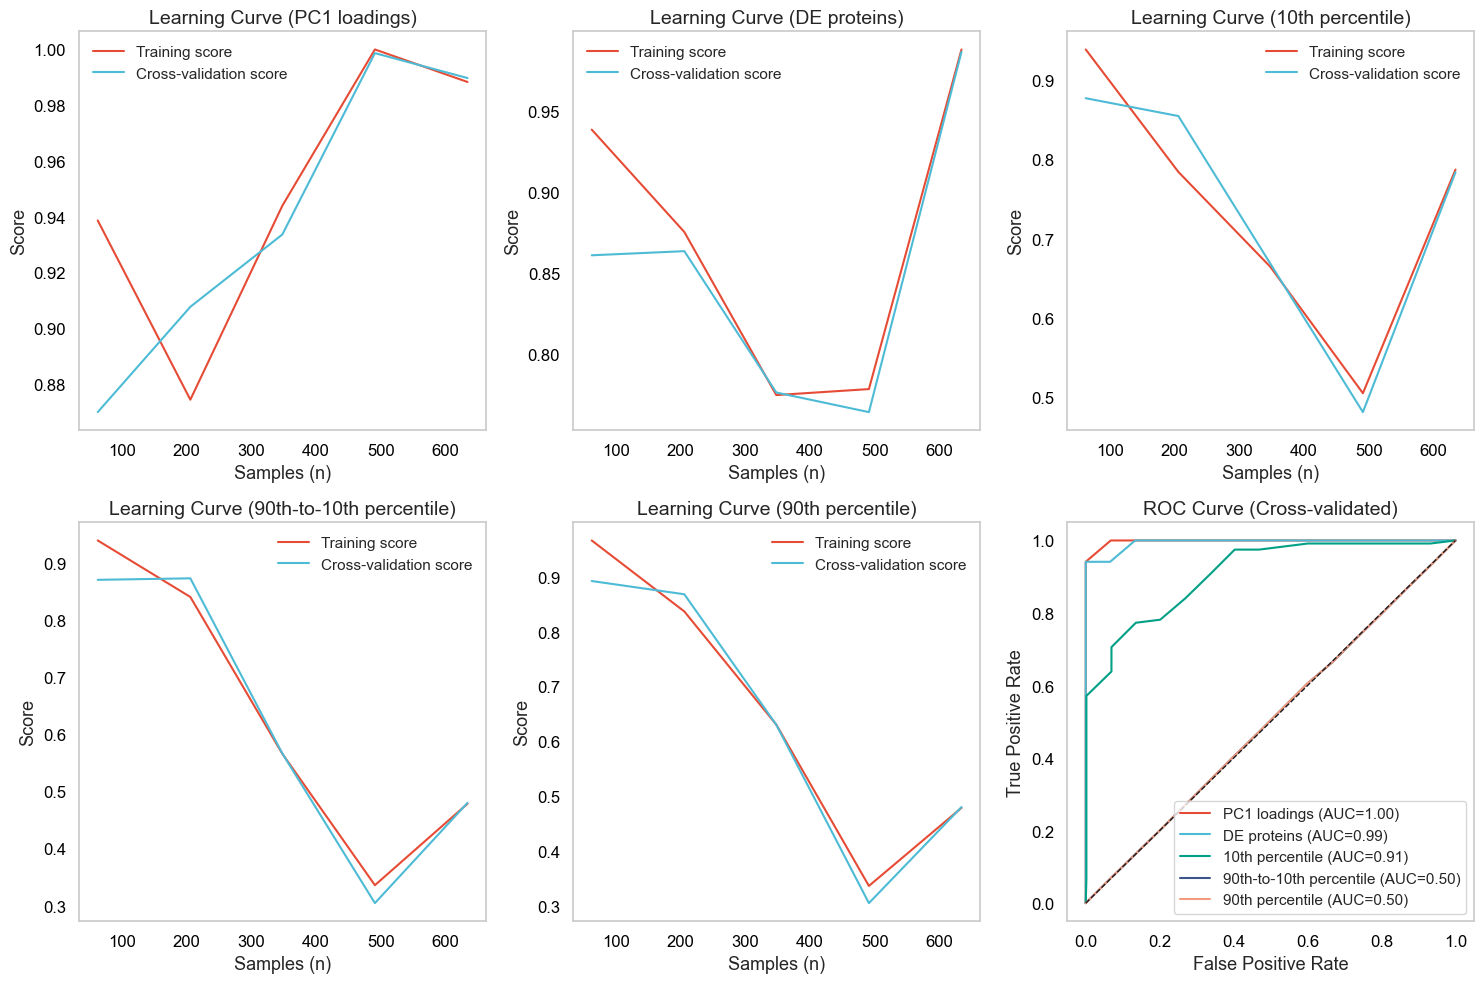

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc
from sklearn.base import clone

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.titlelocation': 'center',
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.loc': 'upper center',
    'legend.frameon': False,
    'axes.facecolor': 'white',
    'axes.grid': False
})
# npg palette approximated from ggsci
npg_palette = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]
sns.set_palette(npg_palette)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# For each dataset, plot learning curves
for idx, (name, (X, y)) in enumerate(XY.items()):
    train_sizes, train_scores, test_scores = learning_curve(
        clone(rf_pipeline), X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    ax = axes[idx]
    ax.plot(train_sizes, train_scores_mean, label='Training score')
    ax.plot(train_sizes, test_scores_mean, label='Cross-validation score')
    ax.set_title(f"Learning Curve ({name})", loc='center')
    ax.set_xlabel("Samples (n)")
    ax.set_ylabel("Score")
    ax.legend(loc='best', frameon=False)

# Plot ROC curves on last subplot
ax = axes[5]
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(res["y"], res["y_pred_proba"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})", color=npg_palette[i % len(npg_palette)])
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_title("ROC Curve (Cross-validated)", loc='center')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.savefig('../output/tarca_et_al_2021/visuals/ai-ml-models.png')
plt.show()

Top 10 most variable proteins: ['DRAK2', 'EF-1-beta', 'Cyclophilin F', 'Enterokinase', 'Sphingosine kinase 1', 'SGTA', 'AMNLS', 'PDGF-BB', 'uPA', 'CD70', 'Stress-induced-phosphoprotein 1', 'CDC37', 'DSC3', 'HSP 40', 'IL-17 RD', 'CNTF', 'ERK-1', 'IMB1', 'TGF-b3', 'CaMKK alpha']
Selected feature matrix shape: (680, 50)


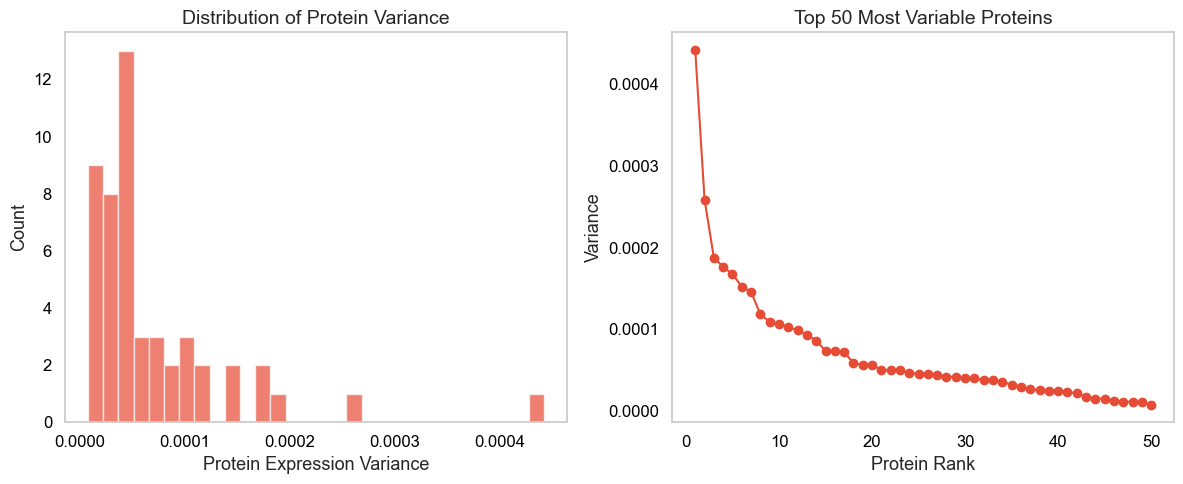

In [12]:
gene_variance = X.var().sort_values(ascending=False)
top_genes = gene_variance.head(50).index.tolist()

print(f"Top 10 most variable proteins: {top_genes[:20]}")

# Create a subset with top variable genes
X_selected = X[top_genes].copy()
print(f"Selected feature matrix shape: {X_selected.shape}")

# Visualize gene variance
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(gene_variance, bins=30, alpha=0.7)
plt.xlabel('Protein Expression Variance')
plt.ylabel('Count')
plt.title('Distribution of Protein Variance')

plt.subplot(1, 2, 2)
plt.plot(range(1, 51), gene_variance.head(50).values, 'o-')
plt.xlabel('Protein Rank')
plt.ylabel('Variance')
plt.title('Top 50 Most Variable Proteins')
plt.tight_layout()
plt.show()